# Statistiques descriptives


Les statistiques qui servent à **décrire** une distribution de données : j'ai tout un tableau de nombres, comment je peux les résumer efficacement et quantitativement ? 

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider # pour des plots interactifs

## 1. Quantiles 

Les quantiles sont des valeurs qui divisent une distribution de données en parties égales : par exemple, le **médian** est le quantile qui divise la distribution en deux parties égales, les **quartiles** sont les quantiles qui divisent la distribution en quatre parties égales, etc.

## 2. Moyenne(s)

### 2.1. Moyenne arithmétique 

C'est la moyenne classique : on additionne tous les nombres et on divise par le nombre de nombres, pas besoin de la présenter ...

### 2.1. Moyenne géométrique : motivation

**Enigme :**

Supposons que j'ai un actif financier d'une valeur initiale de 100 $. 

La première année, il a un rendement de 50%.

La deuxième année, il a un rendement de -50%.

Quelle est la valeur de mon actif au bout de deux ans ? Quel est son taux de croissance moyen ? 

In [4]:
croissances = [0.5, -0.5]
capital = 100

print(f"T = 0, K = {capital}")

for i, croissance in enumerate(croissances):
    capital = capital * (1 + croissance)
    print(f"T = {i + 1}, K = {capital}")


T = 0, K = 100
T = 1, K = 150.0
T = 2, K = 75.0


In [12]:
print(np.sqrt(
    (1+croissances[0])
      *
    (1+croissances[1])) - 1)

-0.1339745962155614


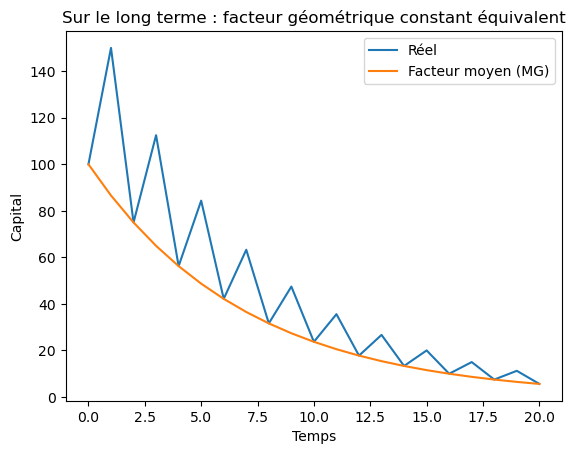

In [ ]:
import pandas as pd

capital = 100
factors_cycle = [1.5, 0.5]   # un cycle de variations
n_cycles = 10                # 10 cycles → 20 périodes

# Construction des facteurs réels
factors_real = factors_cycle * n_cycles

# Moyenne géométrique du cycle
factor_mg = (1.5 * 0.5) ** 0.5

# Trajectoires
real = [capital]
mg = [capital]

for f in factors_real:
    real.append(real[-1] * f)

for _ in factors_real:
    mg.append(mg[-1] * factor_mg)

# Axe du temps
temps = list(range(len(real)))

df = pd.DataFrame({
    "Temps": temps,
    "Réel": real,
    "Facteur moyen (MG)": mg
})

df.plot(x="Temps")
plt.ylabel("Capital")
plt.title("Sur le long terme : facteur géométrique constant équivalent")
plt.show()


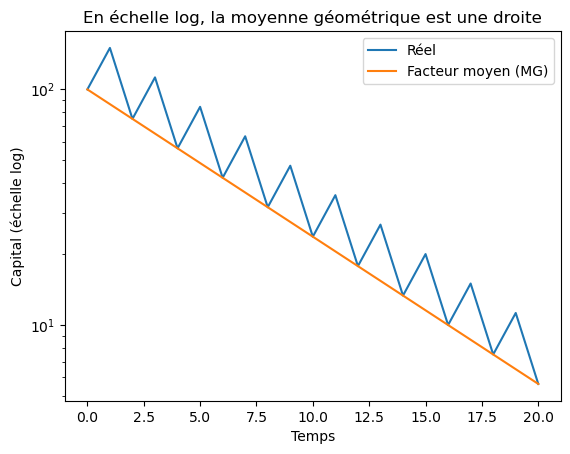

In [15]:
df.plot(x="Temps")
plt.yscale("log")
plt.ylabel("Capital (échelle log)")
plt.title("En échelle log, la moyenne géométrique est une droite")
plt.show()


### 2.3. Moyenne harmonique : motivation

**Enigme:**

Je dois faire un trajet de 200 km en voiture. 

Les 100 premiers km, je suis sur l'autoroute à 100 km/h. 
Les 100 km suivant, je dois aller sur la nationale à 80 km/h.

Sur tout mon trajet, quelle est ma vitesse moyenne ? 

*On rappelle que vitesse = distance / temps*


In [20]:
v = 200 / ((100 / 100) + (100 / 80))
print(f"Vitesse moyenne : {v:.1f}")

Vitesse moyenne : 88.9


> Résumé : 

| Moyenne | Formule | Utilisation |
| --- | --- | --- |
| Moyenne arithmétique | $\frac{1}{n} \sum_{i=1}^n x_i$ | Utilisée pour les données qui sont additionnées, comme les revenus, les dépenses, etc. |
| Moyenne géométrique | $\left( \prod_{i=1}^n x_i \right)^{\frac{1}{n}}$ | Utilisée pour les données qui sont multipliées, comme les taux de croissance, les rendements, etc. |
| Moyenne harmonique | $\frac{n}{\sum_{i=1}^n \frac{1}{x_i}}$ | Utilisée pour les données qui sont inversées, comme les vitesses, le F1-score, etc. |

## 3. Variance et écart type

La variance et l'écart type sont des mesures de la dispersion d'une distribution de données : elles indiquent à quel point les données sont dispersées autour de la moyenne.

In [ ]:

# Fixer des limites de x constantes
x_min, x_max = -20, 20  

def plot_normal(mu=0, sigma=1):
    # Générer des données
    data = np.random.normal(loc=mu, scale=sigma, size=1000)
    
    # Tracer histogramme
    plt.figure(figsize=(8,5))
    plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', range=(x_min, x_max))
    
    # Tracer la courbe théorique
    x = np.linspace(x_min, x_max, 200)
    y = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2))
    plt.plot(x, y, color='red', lw=2)
    
    plt.title(f"Loi normale : μ={mu}, σ={sigma}")
    plt.xlabel("Valeurs")
    plt.ylabel("Densité")
    plt.xlim(x_min, x_max)  # Axe x fixe
    plt.show()

# Sliders interactifs
interact(plot_normal, 
         mu=FloatSlider(value=0, min=-10, max=10, step=0.5, description='Moyenne μ'),
         sigma=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='Écart-type σ'));

interactive(children=(FloatSlider(value=0.0, description='Moyenne μ', max=10.0, min=-10.0, step=0.5), FloatSli…

## 4. Skewness 

La **skewness** (ou coefficient d'asymétrie) décrit l'asymétrie d'une distribution de données : elle indique si les données sont plus concentrées à gauche ou à droite de la moyenne.

La règle est la suivante :

- Si skwewness > 0 : la distribution est asymétrique à droite (plus de données à gauche de la moyenne)
- Si skewness < 0 : la distribution est asymétrique à gauche (plus de données à droite de la moyenne)

<div style="text-align: center;">
    <img src="skewness.png" alt="skewness.png" width="600"/>
</div>


## 5. Statistiques bivariées : covariance et corrélation

Nous avons vu comment décrire une seule variable aléatoire avec des statistiques univariées : la moyenne, la médiane, les quantiles, la variance, etc.

Il peut être intéressant de regarder la relation entre plusieurs variables : est-ce que les données de la variable A sont liées aux données de la variable B ? (pensez à plusieurs colonnes d'un tableau).

Ceci peut être fait avec des statistiques bivariées : la covariance et la corrélation.

La **covariance** est une mesure de la relation linéaire entre deux variables : elle indique si les données de la variable A sont liées aux données de la variable B.

La **corrélation** est une mesure de la relation linéaire entre deux variables : elle indique si les données de la variable A sont liées aux données de la variable B, mais elle est normalisée entre -1 et 1.

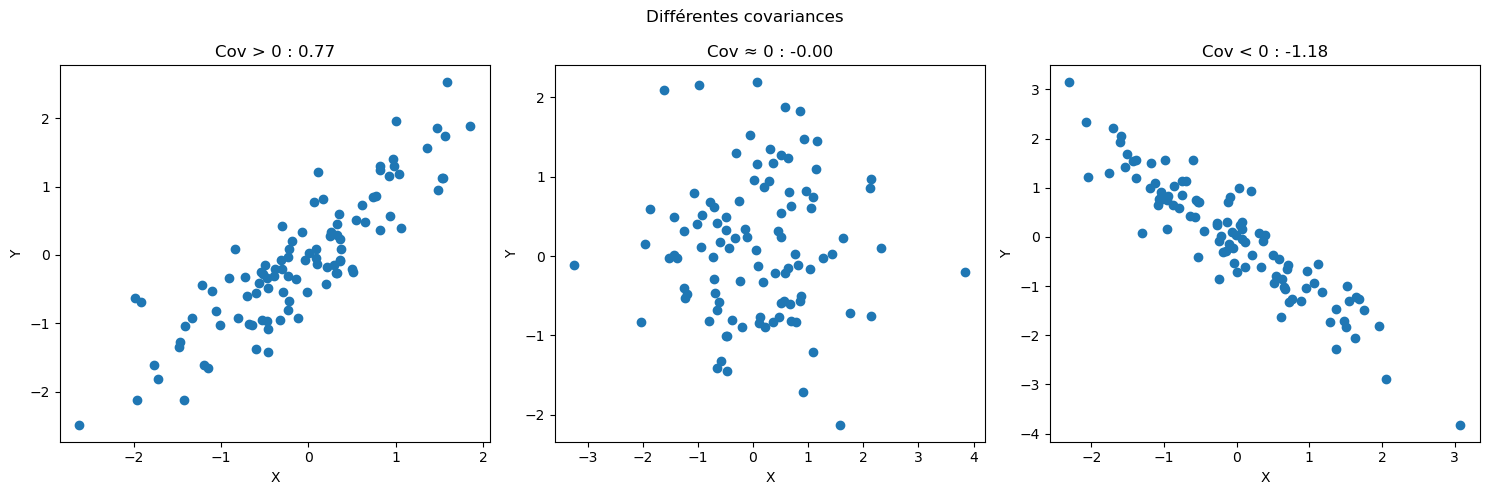

In [35]:

np.random.seed(42)  # pour reproductibilité

#  Covariance positive
x_pos = np.random.randn(100)
y_pos = x_pos + np.random.randn(100)*0.5  # corrélation positive
cov_pos = np.cov(x_pos, y_pos)[0,1]

#  Covariance nulle
x_zero = np.random.randn(100)
y_zero = np.random.randn(100)  # indépendant → covariance proche de 0
cov_zero = np.cov(x_zero, y_zero)[0,1]

#  Covariance négative
x_neg = np.random.randn(100)
y_neg = -x_neg + np.random.randn(100)*0.5  # corrélation négative
cov_neg = np.cov(x_neg, y_neg)[0,1]

# Création des subplots
fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].scatter(x_pos, y_pos)
axes[0].set_title(f"Cov > 0 : {cov_pos:.2f}")

axes[1].scatter(x_zero, y_zero)
axes[1].set_title(f"Cov ≈ 0 : {cov_zero:.2f}")

axes[2].scatter(x_neg, y_neg)
axes[2].set_title(f"Cov < 0 : {cov_neg:.2f}")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("Différentes covariances")
plt.tight_layout()
plt.show()

Il peut être intéressant de regarder les corrélations entre plusieurs variables avec une matrice de corrélation : c'est une matrice carrée qui contient les corrélations entre toutes les paires de variables.

Par exemple on peut s'intéresser aux relations entre différentes caractéristiques d'une fleur : la longueur des pétales, la largeur des pétales, la longueur des sépales, la largeur des sépales.


<div style="text-align: center;">
    <img src="flower.jpeg" alt="flower.jpeg" width="300"/>
</div>


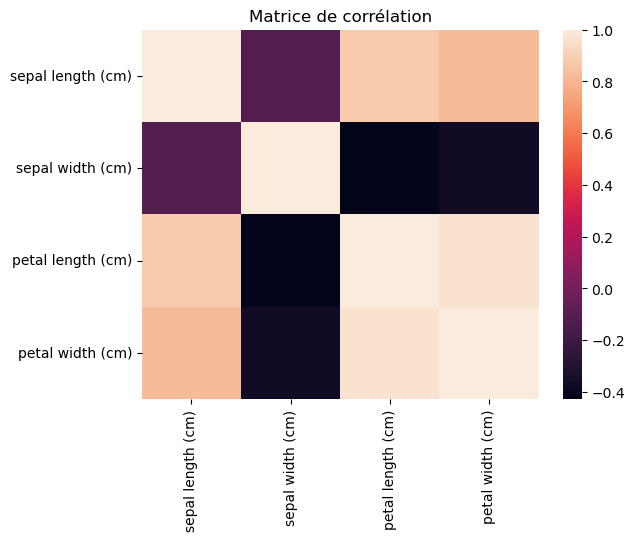

In [32]:
from sklearn.datasets import load_iris
import seaborn as sns 

X, _ = load_iris(as_frame=True , return_X_y=True)

corr = X.corr()

sns.heatmap(corr)
plt.title("Matrice de corrélation");

## A ne pas oublier : décrire c'est bien, décrire et visualiser c'est mieux !

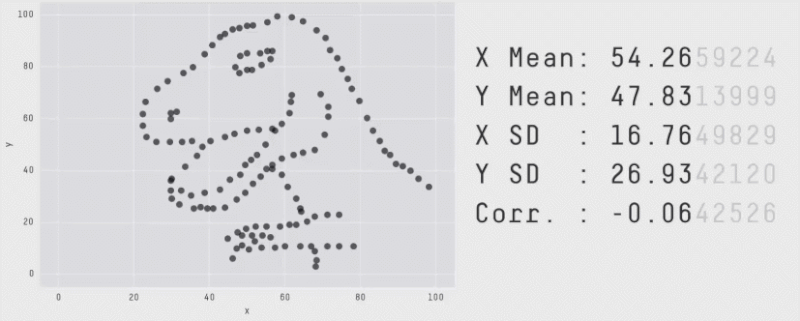